# Build a Reflective Dynamic Planning Agent for Multi-Step Complex Query Analysis with LangGraph

In this project we will be building a Planning Agent which can generate dynamic plans and iterate and update using reflection to help with multi-step complex query analysis.

![](https://i.imgur.com/odnq3de.png)

### Reflective Dynamic Planning Agent for Multi-Step Complex Query Analysis

This project focuses on building a **Reflective Dynamic Planning Agent for Multi-Step Complex Query Analysis**, designed to break down user queries or tasks into manageable steps, execute them iteratively, and update the plan dynamically through reflection and replanning. The components of the system are as follows:

1. **Plan Creation**:
   - The agent begins by analyzing the user's input (topic or question) to create a **step-by-step plan** of sub-questions or steps needed to solve the overall task.
   - Each step is clearly outlined in the **step-by-step plan** for sequential execution.

2. **Step Execution**:
   - The agent executes one step at a time using **OpenAI GPT-4o**.
   - During execution:
     - External tools, such as the **web search tool**, are used to gather required information or data for the step.
     - The result of the executed step is captured and stored in the agent's state.

3. **Reflection and Replanning**:
   - After each step, the system evaluates the results and sends the **overall plan**, **steps executed**, **results**, and **remaining steps** to the **Replanner**.
   - The **Replanner**:
     - Assesses whether the remaining steps need modification based on the current results and any new insights.
     - Updates the remaining steps if necessary, ensuring alignment with the overall objective.
   - This iterative loop ensures adaptability to errors, incomplete data, or unforeseen circumstances.

4. **Dynamic Feedback Loop**:
   - The system monitors the status of the response:
     - If all steps are executed successfully or an error occurs, the process halts.
     - If there are remaining steps, the agent continues executing them one at a time, integrating results dynamically.

5. **Agent State Maintenance**:
   - Throughout the process, the agent maintains a record of:
     - The **original plan**.
     - **Executed steps and their results**.
     - **Remaining steps** for further execution.
   - This stateful approach ensures traceability and transparency in the agent’s decision-making process.

6. **Final Response Compilation**:
   - Once all steps are executed or the process encounters an error, the agent compiles everything to generate the final reponse.





## Install OpenAI, LangGraph and LangChain dependencies

In [1]:
!pip install langchain==0.3.14
!pip install langchain-openai==0.3.0
!pip install langchain-community==0.3.14
!pip install langgraph==0.2.64
!pip install rich

In [2]:
!pip install markitdown

  Using cached numpy-2.3.5-cp313-cp313-macosx_14_0_arm64.whl.metadata (62 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 7.6 MB/s  0:00:01 eta 0:00:01
Using cached numpy-2.3.5-cp313-cp313-macosx_14_0_arm64.whl (5.1 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [markitdown]4 [magika]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-chroma 0.2.0 requires numpy<2.0.0,>=1.26.2; python_version >= "3.12", but you have numpy 2.3.5 which is incompatible.


## Enter Open AI API Key

In [3]:
from getpass import getpass

OPENAI_KEY = getpass('Enter Open AI API Key: ')

## Enter Tavily Search API Key

Get a free API key from [here](https://tavily.com/#api)

In [4]:
TAVILY_API_KEY = getpass('Enter Tavily Search API Key: ')

## Setup Environment Variables

In [5]:
import os

os.environ['OPENAI_API_KEY'] = OPENAI_KEY
os.environ['TAVILY_API_KEY'] = TAVILY_API_KEY

## Utility Functions

- __`process_and_truncate_texts(...)`:__ Helps in truncating the content length of content extracted from the web (documents), this is very useful especially to keep documents within the limit of LLM context windows

In [6]:
import tiktoken

def process_and_truncate_texts(text_docs, max_tokens=127000):
    """
    Calculate token counts for a list of text documents and truncate them to fit within max_tokens.

    Args:
        text_docs (list of str): List of text documents to process.
        max_tokens (int): Maximum token limit for truncation.

    Returns:
        list of str: Truncated list of text documents.
    """
    # Load the tokenizer (adjust the encoding name as per your use case, e.g., gpt-3.5-turbo, gpt-4, etc.)
    encoding = tiktoken.encoding_for_model("gpt-4o")

    # Calculate token counts for each document
    tokenized_docs = []
    for text in text_docs:
        tokens = encoding.encode(text)
        tokenized_docs.append(tokens)

    # Flatten all tokens into a single list
    all_tokens = [token for tokens in tokenized_docs for token in tokens]

    # Truncate to the maximum token limit
    truncated_tokens = all_tokens[:max_tokens]

    # Decode the truncated tokens back to text
    truncated_texts = []
    remaining_tokens = truncated_tokens[:]
    for tokens in tokenized_docs:
        if len(remaining_tokens) >= len(tokens):
            # Add the full document if its tokens fit within the remaining budget
            truncated_texts.append(encoding.decode(tokens))
            remaining_tokens = remaining_tokens[len(tokens):]
        else:
            # Partially add tokens of the last fitting document
            truncated_texts.append(encoding.decode(remaining_tokens))
            break

    return truncated_texts

text_docs = [
        "This is the first document. It has some content.",
        "The second document might have more content than the first.",
        "This is the third document. It also has its own content.",
        # Add more documents as needed
    ]

truncated_texts = process_and_truncate_texts(text_docs, max_tokens=20)
truncated_texts

['This is the first document. It has some content.',
 'The second document might have more content than the']

- __`search_web_extract_info(...)`:__ Leverages Tavily to get top search results for a query and then uses Tavily extracted raw content to get the full website data and then calls `process_and_truncate_texts(...)` on the extracted documents to truncate them to a specific token limit

In [7]:
from langchain_core.tools import tool
from langchain_community.utilities.tavily_search import TavilySearchAPIWrapper

tavily_search = TavilySearchAPIWrapper()


def search_web_extract_info(query: str) -> list:
    """Search the web for a query and extracts useful information from the search links."""
    print('Calling web search tool for query:', query)
    results = tavily_search.raw_results(query=query,
                                        max_results=3,
                                        search_depth='advanced',
                                        include_answer=False,
                                        include_raw_content=True)
    docs = [doc['raw_content'] for doc in results['results']]
    docs = process_and_truncate_texts(docs, max_tokens=127000)
    return docs

In [8]:
docs = search_web_extract_info('what is langgraph')

Calling web search tool for query: what is langgraph


In [9]:
len(docs)

3

In [10]:
docs[0]

'LangGraph overview - Docs by LangChain\n\n===============\n\n[Skip to main content](https://docs.langchain.com/oss/python/langgraph/overview#content-area)\n\n[Docs by LangChain home page![Image 1: light logo](https://mintcdn.com/langchain-5e9cc07a/Xbr8HuVd9jPi6qTU/images/brand/langchain-docs-teal.svg?fit=max&auto=format&n=Xbr8HuVd9jPi6qTU&q=85&s=16111530672bf976cb54ef2143478342)![Image 2: dark logo](https://mintcdn.com/langchain-5e9cc07a/Xbr8HuVd9jPi6qTU/images/brand/langchain-docs-lilac.svg?fit=max&auto=format&n=Xbr8HuVd9jPi6qTU&q=85&s=b70fb1a2208670492ef94aef14b680be)](https://docs.langchain.com/)LangChain + LangGraph\n\nSearch...\n\nCtrl K\n\n*   [GitHub](https://github.com/langchain-ai)\n*   [Try LangSmith](https://smith.langchain.com/)\n*   [Try LangSmith](https://smith.langchain.com/)\n\nSearch...\n\nNavigation\n\nLangGraph overview\n\n[LangChain](https://docs.langchain.com/oss/python/langchain/overview)[LangGraph](https://docs.langchain.com/oss/python/langgraph/overview)[Deep A

## Build the Web Research Sub-Agent graph - Tool-Use Agent

This agent or to be more accurate sub-agent will be used in our planner to get information for each query or step in the overall plan

In [22]:
from typing import Annotated

from langchain_openai import ChatOpenAI
from langchain_core.messages import BaseMessage
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.messages import HumanMessage, SystemMessage, RemoveMessage
from langchain_core.messages import trim_messages



class State(TypedDict):
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)

tools = [search_web_extract_info]
llm = ChatOpenAI(model="gpt-4o", temperature=0)
llm_with_tools = llm.bind_tools(tools)



SYS_MSG = SystemMessage(content="Act as a helpful assistant and answer user questions")
# def chatbot(state: State):
#     messages = trim_messages(
#             state["messages"],
#             max_tokens=127000,
#             strategy="last",
#             token_counter=ChatOpenAI(model="gpt-4o"),
#             allow_partial=True,
#     )
#     return {"messages": [llm_with_tools.invoke([SYS_MSG] + messages)]}

def chatbot(state: State):
    messages = trim_messages(
        state["messages"],
        max_tokens=127000,
        strategy="last",  # Keep the most recent messages
        token_counter=ChatOpenAI(model="gpt-4o"),
        allow_partial=False,  # Change this to False
        start_on="human",  # Always start with a human message
        end_on=("human", "tool"),  # Ensure we end on valid message types
        include_system=True,  # Keep system messages
    )
    return {"messages": [llm_with_tools.invoke([SYS_MSG] + messages)]}


graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
    ["tools", END]
)
# Any time a tool is called, we return to the chatbot to decide the next step
graph_builder.add_edge("tools", "chatbot")
graph_builder.set_entry_point("chatbot")
react_agent = graph_builder.compile()

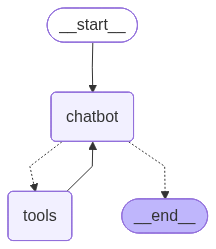

In [23]:
from IPython.display import Image, display

display(Image(react_agent.get_graph().draw_mermaid_png()))

## Test the Web Research Sub-Agent

In [24]:
def call_agent(agent, prompt, user_config={"configurable": {"thread_id": "any"}}):
    events = agent.stream(
        {"messages": [{"role": "user", "content": prompt}]},
        user_config,
        stream_mode="values",
    )

    for event in events:
        event["messages"][-1].pretty_print()

In [25]:
user_prompt = "Can you tell me about langgraph?"

call_agent(agent=react_agent,
           prompt=user_prompt)

================================ Human Message =================================

Can you tell me about langgraph?
================================== Ai Message ==================================
Tool Calls:
  search_web_extract_info (call_0DgXG5Mt0LN8sM1QNNgDdaN7)
 Call ID: call_0DgXG5Mt0LN8sM1QNNgDdaN7
  Args:
    query: langgraph
Calling web search tool for query: langgraph
================================= Tool Message =================================
Name: search_web_extract_info

["# What is LangGraph?\n\nLast Updated : \n10 Oct, 2025\n\nSuggest changes\n\n1 Likes\n\nLangGraph is an open-source framework built by [LangChain](https://www.geeksforgeeks.org/artificial-intelligence/introduction-to-langchain/) that streamlines the creation and management of AI agent workflows. At its core, LangGraph combines large language models (LLMs) with graph-based architectures allowing developers to map, organize and optimize how AI agents interact and make decisions.\n\nBy treating workflows 

In [26]:
user_prompt = "Who are the key founders of Nvidia, what did they previously do and how did nvidia become such a huge company with a huge market cap?"

call_agent(agent=react_agent,
           prompt=user_prompt)

================================ Human Message =================================

Who are the key founders of Nvidia, what did they previously do and how did nvidia become such a huge company with a huge market cap?
================================== Ai Message ==================================
Tool Calls:
  search_web_extract_info (call_hLkvcS4ABSGwOn82nqajK7nC)
 Call ID: call_hLkvcS4ABSGwOn82nqajK7nC
  Args:
    query: Nvidia founders and their previous work
  search_web_extract_info (call_Ad2KKDEUQUl9bd5VmsumY4gF)
 Call ID: call_Ad2KKDEUQUl9bd5VmsumY4gF
  Args:
    query: Nvidia company growth and market cap history
Calling web search tool for query: Nvidia founders and their previous work
Calling web search tool for query: Nvidia company growth and market cap history
================================= Tool Message =================================
Name: search_web_extract_info

["[Log In](/login/) [Sign Up](/pro/)\n\nNVIDIA Corporation (NVDA)\n\nNASDAQ: NVDA · Real-Time Price · USD

In [27]:
user_prompt = """who is the founder of microsoft, their hometown and history of founder and the company?
               """

call_agent(agent=react_agent,
           prompt=user_prompt)

================================ Human Message =================================

who is the founder of microsoft, their hometown and history of founder and the company?
               
================================== Ai Message ==================================
Tool Calls:
  search_web_extract_info (call_NWKbgh8rGjwmoDJKplYlM9VJ)
 Call ID: call_NWKbgh8rGjwmoDJKplYlM9VJ
  Args:
    query: founder of Microsoft
  search_web_extract_info (call_n4p8PimC4kmRLrjePViAPiPO)
 Call ID: call_n4p8PimC4kmRLrjePViAPiPO
  Args:
    query: hometown of Bill Gates
  search_web_extract_info (call_y0gmkO3oMaGCOyI5RtYfxjr6)
 Call ID: call_y0gmkO3oMaGCOyI5RtYfxjr6
  Args:
    query: history of Bill Gates
  search_web_extract_info (call_LAN3XdMnD7Y5Bqhe2n28hFfG)
 Call ID: call_LAN3XdMnD7Y5Bqhe2n28hFfG
  Args:
    query: history of Microsoft
Calling web search tool for query: founder of Microsoft
Calling web search tool for query: hometown of Bill Gates
Calling web search tool for query: history of Bill G

## Create State Schema for our Planning Agent

In [28]:
import operator
from typing import Annotated, List, Tuple
from typing_extensions import TypedDict

# state of the executed plan including overall plan, current status in terms of steps executed and output
# response would either be the final result or errors encountered
class PlanExecute(TypedDict):
    input: str
    plan: List[str]
    past_steps: Annotated[List[Tuple], operator.add]
    response: str

## Create AI Workflow for Plan Generation

In [29]:
from pydantic import BaseModel, Field
from typing import Literal, Union

class Plan(BaseModel):
    """Plan to follow in future to get to a well-researched output for user query"""
    type: Literal["Plan"]
    steps: List[str] = Field(
        description="Different steps to follow in the plan, should be in sorted order"
    )

In [30]:
from langchain_core.prompts import ChatPromptTemplate

planner_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """Analyze the given query or task in detail and follow these rules to make a plan:
                - Come up with a simple step by step plan (max 5 steps).
                - This plan should involve individual tasks, that if executed correctly will yield the correct answer.
                - Do not add any extra superfluous steps.
                - The result of the final step should lead to the final answer.
                - Make sure that each step has all the information needed - do not skip steps.
            """,
        ),
        ("placeholder", "{messages}"),
    ]
)

In [31]:
llm_planner = ChatOpenAI(model="gpt-4o-mini", temperature=0)
planner = (
            planner_prompt
                |
            llm_planner.with_structured_output(Plan) #function calling because we are using structured output
)

In [32]:
res = planner.invoke(
    {
        "messages": [
            ("user", "who is the founder of microsoft")
        ]
    }
)

print(res)

type='Plan' steps=['Identify the key figures associated with the founding of Microsoft.', 'Research the history of Microsoft to determine its founding date and the individuals involved.', 'Confirm the roles of Bill Gates and Paul Allen in the establishment of Microsoft.', 'Verify any additional contributions or roles of other early team members if relevant.', 'Conclude that Bill Gates and Paul Allen are the co-founders of Microsoft.']


In [33]:
res

Plan(type='Plan', steps=['Identify the key figures associated with the founding of Microsoft.', 'Research the history of Microsoft to determine its founding date and the individuals involved.', 'Confirm the roles of Bill Gates and Paul Allen in the establishment of Microsoft.', 'Verify any additional contributions or roles of other early team members if relevant.', 'Conclude that Bill Gates and Paul Allen are the co-founders of Microsoft.'])

## Create AI Workflow for Replanner (with reflection)

In [34]:
from typing import Union

class Response(BaseModel):
    """Response generated for the user."""
    type: Literal["Response"]
    response: str


class Act(BaseModel):
    """Action to perform."""

    action: Union[Response, Plan] = Field(
        description="Action to perform. If you want to respond to user, use Response. "
        "If you need to further use tools to get the answer, use Plan."
    )

In [35]:
replanner_prompt = ChatPromptTemplate.from_template(
    """For the given objective, come up with a simple step by step plan.
       This plan should involve individual tasks, that if executed correctly will yield the correct answer.
       Do not add any extra superfluous steps.
       The result of the final step should be the final answer.
       Make sure that each step has all the information needed - do not skip steps.

       Your main objective was this:
       {input}

       Your original plan was this:
       {plan}

       You have currently done the following steps (with their corresponding results):
       {past_steps}

       Update your plan accordingly as necessary.

       If no more steps are needed then analyze all the information collected so far and generate a detailed formatted answer in Markdown.
       When generating the final response in markdown, if there are special characters in the text, such as the dollar symbol,
       ensure they are escaped properly for correct rendering e.g $25.5 should become \$25.5

       Otherwise, fill out the plan.
       Only add steps to the plan that still NEED to be done.
       Do NOT return previously done steps as part of the plan."""
)

llm_replanner = ChatOpenAI(model="gpt-4o-mini", temperature=0)

replanner = (
                replanner_prompt
                    |
                llm_replanner.with_structured_output(Act)
)

<>:21: SyntaxWarning: invalid escape sequence '\$'
<>:21: SyntaxWarning: invalid escape sequence '\$'
/var/folders/b2/_3vm0kv95fx3hvhfst25c46r0000gp/T/ipykernel_43430/2166429039.py:21: SyntaxWarning: invalid escape sequence '\$'
  ensure they are escaped properly for correct rendering e.g $25.5 should become \$25.5


## Create Node Function for Plan Generation

Uses the Planner AI Workflow from above to generate a plan for the given user query

In [36]:
async def plan_step(state: PlanExecute):
    plan = await planner.ainvoke({"messages": [("user", state["input"])]})
    return {"plan": plan.steps}

## Create Node Function for Plan Step Execution

Executes the current step in the plan using the researcher sub-agent

In [37]:
react_agent = graph_builder.compile() # compile and prepare the researcher sub-agent

async def execute_step(state: PlanExecute):
    plan = state["plan"]
    past_steps = state['past_steps']
    if not plan:  # Check if plan is empty
        return {
            "past_steps": [],
            "response": "No steps to execute in the plan."
        }

    plan_str = "\n".join(f"{i+1}. {step}" for i, step in enumerate(plan))
    print('=== plan str ===')
    print(plan_str)
    print('=== end of plan str ===')
    task = plan[0]
    task_formatted = f"""Given the following plan:
                        {plan_str}

                         You are tasked with executing step {1}, {task} only.

                         Here are the past steps already executed, use this information also as needed.
                         {past_steps}

                         Call tools only when you need more information.
                         If doing web search optimize the query for search before tool calling
                         otherwise refer to all the information you have to solve the step.
                         Do NOT call tools for analyzing existing information or compiling reports
                         or formatting documents.
                         """

    agent_response = await react_agent.ainvoke(
        {"messages": [("user", task_formatted)]}
    )
    return {
        "past_steps": [(task, agent_response["messages"][-1].content)],
    }

## Create Node Function for Replanner

Updates the current plan's next steps if needed by reflecting on the past steps executed using the Replanner AI workflow from above

In [38]:
async def replan_step(state: PlanExecute):
    try:
        output = await replanner.ainvoke(state)
        print('=== replanner output ===')
        print(output)
        print('=== end of replanner output ===')

        # Handle dict response
        if isinstance(output, dict) and 'Response' in output:
            return {"response": output['Response']}

        # Handle proper Act instance
        if isinstance(output.action, Response):
            return {"response": output.action.response}
        else:
            return {"plan": output.action.steps}
    except Exception as e:
        print(f"Error in replan_step: {e}")
        return {"response": str(output.get('Response', "An error occurred processing the response."))}

## Create Conditional Edge Function for Stopping the Agent

Stops the agent once all steps have been executed or there is an error

In [39]:
from langgraph.graph import END

def should_end(state: PlanExecute):
    if "response" in state and state["response"]:
        return END
    else:
        return "react_agent"

## Build Planner Agent Graph

In [40]:
from langgraph.graph import StateGraph, START

plan_graph = StateGraph(PlanExecute)

# Add the plan node
plan_graph.add_node("planner", plan_step)
# Add the execution step
plan_graph.add_node("react_agent", execute_step)
# Add a replan node
plan_graph.add_node("replanner", replan_step)

# From plan we go to agent
plan_graph.add_edge("planner", "react_agent")
# From agent, we replanner
plan_graph.add_edge("react_agent", "replanner")
plan_graph.add_conditional_edges(
    "replanner",
    # Next, we pass in the function that will determine which node is called next.
    should_end,
    ["react_agent", END]
)
plan_graph.set_entry_point("planner")
# Finally, we compile it!
# This compiles it into a LangChain Runnable,
# meaning you can use it as you would any other runnable
planner_agent = plan_graph.compile()

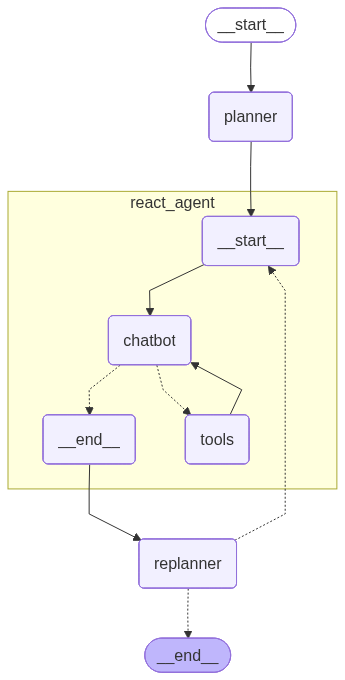

In [41]:
display(Image(planner_agent.get_graph(xray=True).draw_mermaid_png()))

## Run and Test Planner Agent

In [42]:
from IPython.display import display
from rich.markdown import Markdown as RichMarkdown


async def call_planner_agent(agent, prompt, config={"recursion_limit": 50}, verbose=False):
    events = agent.astream(
        prompt,
        config,
        stream_mode="values",
    )

    async for event in events:
        for k, v in event.items():
            if verbose:
                if k != "__end__":
                    display(RichMarkdown(repr(k) + ' -> ' + repr(v)))
            if k == 'response':
                print('='*50)
                print('Response:')
                display(RichMarkdown(v))


In [43]:
prompt = {"input": "who is the founder of microsoft, their hometown and history of founder and the company?"}
await call_planner_agent(agent=planner_agent,
                         prompt=prompt,
                         verbose=True)

'input' -> 'who is the founder of microsoft, their hometown and history of founder and the company?'

'past_steps' -> []

'input' -> 'who is the founder of microsoft, their hometown and history of founder and the company?'

'plan' -> ['Identify the founder of Microsoft, which is Bill Gates.', "Research Bill Gates' hometown, which is     
Seattle, Washington.", "Gather information about Bill Gates' early life, education, and how he became interested in
computers.", 'Investigate the history of Microsoft, including its founding year (1975) and key milestones in its   
development.', 'Summarize the relationship between Bill Gates and Microsoft, including his role in the company and 
its impact on the technology industry.']

'past_steps' -> []

...

'plan' -> ['Compile all gathered information into a cohesive response that includes the founder of Microsoft, their
hometown, and the history of both the founder and the company.']

'past_steps' -> [('Identify the founder of Microsoft, which is Bill Gates.', 'The founder of Microsoft is Bill     
Gates.'), ("Research Bill Gates' hometown, which is Seattle, Washington.", 'Seattle, Washington, is a vibrant city 
known for its rich history, diverse culture, and significant contributions to technology and music. Here are some  
key aspects of Seattle:\n\n1. Geography and Environment: Seattle is located between Puget Sound and Lake           
Washington, surrounded by the Olympic and Cascade mountains. This unique geography gives it a mild oceanic climate,
supporting lush greenery, which is why it's nicknamed "The Emerald City."\n\n2. History: The area has been         
inhabited for thousands of years, originally by Native American tribes such as the Duwamish. European settlers     
arrived in the mid-19th century, and the city was named after Chief Seattle, a leader of the local tribes.\n\n3.   
Economy: Seattle has a diverse economy with strong sectors in technology, aerospace, and maritime industries. It is
home to major companies like Amazon and Microsoft, which have significantly influenced its growth and              
development.\n\n4. Culture and Arts: The city is a cultural hub with numerous museums, theaters, and music venues. 
It played a pivotal role in the grunge music movement of the 1990s, with bands like Nirvana and Pearl Jam          
originating there.\n\n5. Landmarks: Iconic landmarks include the Space Needle, Pike Place Market, and the Museum of
Pop Culture. The city is also known for its coffee culture, being the birthplace of Starbucks.\n\n6. Community and 
Sustainability: Seattle is known for its environmental consciousness, with extensive recycling programs and green  
spaces. The city supports sustainable living and has a strong community focus on environmental                     
responsibility.\n\nSeattle's unique blend of natural beauty, cultural richness, and economic vitality makes it a   
standout city on the West Coast of the United States.'), ("Gather information about Bill Gates' early life,        
including his birth date (October 28, 1955) and family background.", "Based on the information provided, I will    
gather details about Bill Gates' early life, including his birth date and family background.\n\n1. Birth Date: Bill
Gates was born on October 28, 1955.\n\n2. Family Background:\n   - Parents: Bill Gates was born to William H. Gates
Sr. and Mary Maxwell Gates.\n   - Father: William H. Gates Sr. was a prominent lawyer.\n   - Mother: Mary Maxwell  
Gates was a businesswoman and served on the board of directors for First Interstate BancSystem and the United      
Way.\n   - Siblings: Bill Gates has two sisters, Kristi (Kristianne) and Libby.\n\n3. Early Life:\n   - Bill Gates 
grew up in Seattle, Washington, which is known for its rich history and significant contributions to technology and
music.\n   - He showed an early interest in computers and programming, which later influenced his career           
path.\n\nThis information provides a comprehensive overview of Bill Gates' early life, including his birth date and
family background. If you need more detailed information or specific aspects of his early life, please let me      
know!"), ("Investigate Bill Gates' education, focusing on his time at Harvard University and his decision to drop  
out to start Microsoft.", "To investigate Bill Gates' education, focusing on his time at Harvard University and his
decision to drop out to start Microsoft, we can summarize the following information:\n\n1. Education at Harvard    
University:\n   - Bill Gates enrolled at Harvard University in 1973. He was a pre-law major but took a strong      
interest in mathematics and computer science.\n   - During his time at Harvard, Gates met Steve Ballmer, who would 
later become the CEO of Microsoft.\n   - Gates spent much of his time at Harvard working on computer projects,     
including developing a version of the programming langua

'response' -> "# Microsoft: Founder, Hometown, and History\n\n## Founder of Microsoft\nMicrosoft was founded by    
Bill Gates and Paul Allen. Bill Gates is the most recognized founder, having played a pivotal role in the company's
development and growth.\n\n## Hometown of Bill Gates\nBill Gates was born and raised in Seattle, Washington.       
Seattle is a vibrant city known for its rich history, diverse culture, and significant contributions to technology 
and music. It is located between Puget Sound and Lake Washington, surrounded by the Olympic and Cascade mountains. 
The city is home to major companies like Amazon and Microsoft, which have significantly influenced its growth and  
development.\n\n## History of Bill Gates\nBill Gates was born on October 28, 1955, to William H. Gates Sr. and Mary
Maxwell Gates. He grew up in Seattle, Washington, and showed an early interest in computers and programming. Gates 
enrolled at Harvard University in 1973, where he met Steve Ballmer, who would later become the CEO of Microsoft. In
1975, Gates decided to leave Harvard to pursue his passion for software development, co-founding Microsoft with his
childhood friend, Paul Allen.\n\n## History of Microsoft\nMicrosoft was founded on April 4, 1975, by Bill Gates and
Paul Allen. The company was initially established to create software for the Altair 8800, an early personal        
computer. Their first product was a version of the BASIC programming language. In 1981, Microsoft released MS-DOS, 
which became the foundation for the company's success in the personal computer market. Microsoft launched the first
version of Windows in 1985, marking the beginning of its dominance in the operating system market.\n\nThroughout   
the late 1980s and 1990s, Microsoft continued to develop and release new versions of Windows, each with improved   
features and capabilities. The company expanded its product offerings to include software applications like        
Microsoft Office, gaming with the Xbox console, cloud computing with Azure, and various hardware products. By the  
late 1990s and early 2000s, Microsoft had established itself as a global leader in the technology industry, playing
a crucial role in the growth of the personal computer industry.\n\nThese milestones highlight Microsoft's journey  
from a small software startup to a dominant force in the technology industry, driven by its innovative products and
strategic vision."

Response:


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                    Microsoft: Founder, Hometown, and History                                    ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛


                                               Founder of Microsoft                                                

Microsoft was founded by Bill Gates and Paul Allen. Bill Gates is the most recognized founder, having played a     
pivotal role in the company's development and growth.                                                              


                                              Hometown of Bill Gates                                               

Bill Gates was born and raised in Seattle, Washington. Seattle is a vibrant city known for its rich history,       
diverse culture, and significant contributions to technology and music. It is located between Puget Sound and Lake 
Washington, surrounded by the Olympic and Cascade mountains. The city is home to major companies like Amazon and   
Microsoft, which have significantly influenced its growth and development.                                         


                                               History of Bill Gates                                               

Bill Gates was born on October 28, 1955, to William H. Gates Sr. and Mary Maxwell Gates. He grew up in Seattle,    
Washington, and showed an early interest in computers and programming. Gates enrolled at Harvard University in     
1973, where he met Steve Ballmer, who would later become the CEO of Microsoft. In 1975, Gates decided to leave     
Harvard to pursue his passion for software development, co-founding Microsoft with his childhood friend, Paul      
Allen.                                                                                                             


                                               History of Microsoft                                                

Microsoft was founded on April 4, 1975, by Bill Gates and Paul Allen. The company was initially established to     
create software for the Altair 8800, an early personal computer. Their first product was a version of the BASIC    
programming language. In 1981, Microsoft released MS-DOS, which became the foundation for the company's success in 
the personal computer market. Microsoft launched the first version of Windows in 1985, marking the beginning of its
dominance in the operating system market.                                                                          

Throughout the late 1980s and 1990s, Microsoft continued to develop and release new versions of Windows, each with 
improved features and capabilities. The company expanded its product offerings to include software applications    
like Microsoft Office, gaming with the Xbox console, cloud computing with Azure, and various hardware products. By 
the late 1990s and early 2000s, Microsoft had established itself as a global leader in the technology industry,    
playing a crucial role in the growth of the personal computer industry.                                            

These milestones highlight Microsoft's journey from a small software startup to a dominant force in the technology 
industry, driven by its innovative products and strategic vision.

In [44]:
prompt = {"input": "Who are the key founders of Nvidia, what did they previously do and how did nvidia become such a huge company with a huge market cap?"}
await call_planner_agent(agent=planner_agent,
                         prompt=prompt)

=== plan str ===
1. Identify the key founders of Nvidia and their roles in the company.
2. Research the professional backgrounds of each founder prior to Nvidia, including their previous companies and positions.
3. Investigate the major milestones and innovations that contributed to Nvidia's growth and market cap, such as product launches and technological advancements.
4. Analyze the market trends and industry shifts that favored Nvidia's growth, including the rise of gaming, AI, and data centers.
5. Summarize how these factors combined to establish Nvidia as a leading company in the tech industry with a significant market cap.
=== end of plan str ===
Calling web search tool for query: Nvidia founders and their roles
=== replanner output ===
action=Plan(type='Plan', steps=['Research the professional backgrounds of Jensen Huang, Chris Malachowsky, and Curtis Priem prior to Nvidia, including their previous companies and positions.', "Investigate the major milestones and innovations that

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                             Key Founders of Nvidia and Their Impact on the Company                              ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

Nvidia Corporation, a leading force in the technology industry, was founded in 1993 by three visionary engineers:  
Jensen Huang, Chris Malachowsky, and Curtis Priem. Each founder brought a unique set of skills and experiences that
were crucial in shaping Nvidia's trajectory.                                                                       


                                               Founders' Backgrounds                                               

                                                   Jensen Huang                                                    

 • Education: Bachelor's degree in Electrical Engineering from Oregon State University and a Master's degree in    
   Electrical Engineering from Stanford University.                                                                
 • Career: Before founding Nvidia, Huang worked as a microchip designer at Advanced Micro Devices (AMD) and LSI    
   Logic, where he gained valuable experience in designing microprocessors and graphics accelerator cards. His     
   leadership and strategic vision have been instrumental in guiding Nvidia through various phases of growth and   
   innovation, particularly in the development of GPUs and the expansion into AI and data centers.                 

                                                 Chris Malachowsky                                                 

 • Education: Bachelor's degree in Electrical Engineering from the University of Florida and a Master's degree in  
   Computer Science from Santa Clara University.                                                                   
 • Career: Prior to Nvidia, he held engineering and technical leadership positions at Hewlett-Packard (HP) and Sun 
   Microsystems. Malachowsky's expertise in integrated-circuit design and computer graphics has been vital in      
   Nvidia's engineering and product development.                                                                   

                                                   Curtis Priem                                                    

 • Education: Bachelor's degree in Electrical Engineering from Rensselaer Polytechnic Institute.                   
 • Career: Before co-founding Nvidia, Priem was known for designing the first graphics processor for the PC, the   
   IBM Professional Graphics Adapter, and developing the GX graphics chip at Sun Microsystems. His pioneering work 
   in graphics technology laid the foundation for Nvidia's early technological advancements.                       


                                         Major Milestones and Innovations                                          

Nvidia's growth and market cap have been significantly influenced by several major milestones and innovations:     

 1 Founding and Early Development (1993-1999):                                                                     
    • Nvidia was founded in 1993, focusing on graphics-based computing and video games.                            
    • The release of the RIVA 128 in 1997 marked Nvidia's first major success in 3D graphics.                      
    • In 1999, Nvidia introduced the GeForce 256, the first GPU, transforming computer graphics by enabling        
      advanced 3D rendering.                                                                                       
 2 Expansion and Dominance in the GPU Market (2000-2010):                                                          
    • The launch of the GeForce 256 positioned Nvidia at the forefront of the graphics industry.                   
    • Nvidia acquired 3dfx Interactive in 2